In [1]:
import sqlite3
from pathlib import Path
import sys

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR / "src"))

from stats.bivariate import desc_analysis as desc, plots as plt, contingency as cont
from stats import helpers as hlp

con = sqlite3.connect(BASE_DIR / "data" / "IST-dataset.db")

              Sender capitulation  Target complete acquiescence  \
Multilateral                    6                            70   
Unilateral                     44                            35   

              Target partial acquiescence  
Multilateral                           50  
Unilateral                             55  


# Bivariate distributions

## Duration

Variable pairs:

- **expiry-date** x **duration**
- **review** x **duration**
- **requirement-termination** x **duration**

In [2]:
print("\nFrequency distribution of expiry-date by duration intervall\n")
desc.get_expiry_x_duration(con)


Frequency distribution of expiry-date by duration intervall



0–6m        6m–1y        1–2y        2–5y        5–10y         \
               Abs. Rel(%)  Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)  Abs. Rel(%)   
Missing           0    0.0     2   28.6    0    0.0    1   14.3     2   28.6   
Not stipulated   51   15.8    34   10.6   40   12.4   94   29.2    54   16.8   
Stipulated        2    2.9     2    2.9   12   17.1   26   37.1    11   15.7   
TOTAL            53   13.3    38    9.5   52   13.0  121   30.3    67   16.8   

               10–20y        20+y        Total  
                 Abs. Rel(%) Abs. Rel(%)        
Missing             2   28.6    0    0.0     7  
Not stipulated     30    9.3   19    5.9   322  
Stipulated         11   15.7    6    8.6    70  
TOTAL              43   10.8   25    6.3   399

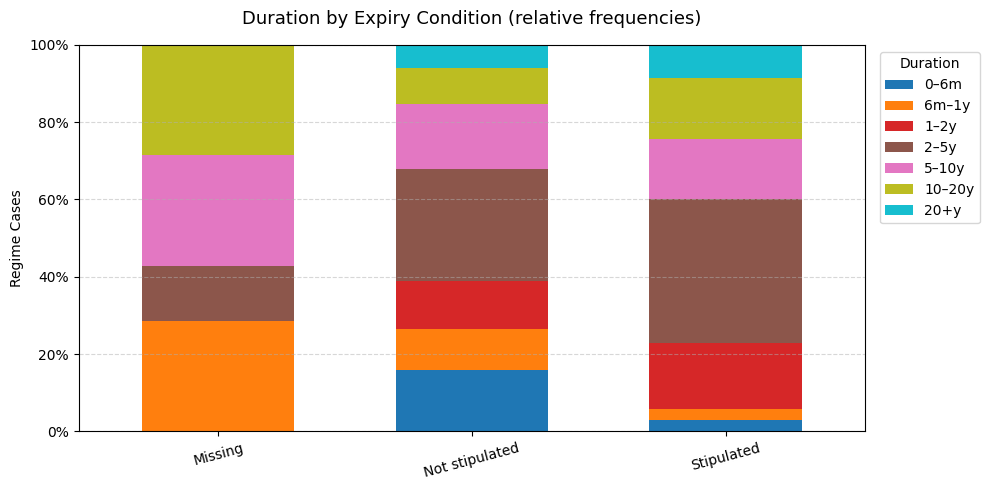

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/expiry_x_duration.svg


In [3]:
plt.plot_expiry_x_duration(con)

In [4]:
print("\nFrequency distribution of review by duration intervall\n")
desc.get_review_x_duration(con)


Frequency distribution of review by duration intervall



0–6m        6m–1y        1–2y        2–5y        5–10y         \
          Abs. Rel(%)  Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)  Abs. Rel(%)   
Missing      0    0.0     2   22.2    1   11.1    1   11.1     3   33.3   
No review   38   15.2    32   12.8   32   12.8   82   32.8    36   14.4   
Review      15   10.7     4    2.9   19   13.6   38   27.1    28   20.0   
TOTAL       53   13.3    38    9.5   52   13.0  121   30.3    67   16.8   

          10–20y        20+y        Total  
            Abs. Rel(%) Abs. Rel(%)        
Missing        2   22.2    0    0.0     9  
No review     17    6.8   13    5.2   250  
Review        24   17.1   12    8.6   140  
TOTAL         43   10.8   25    6.3   399

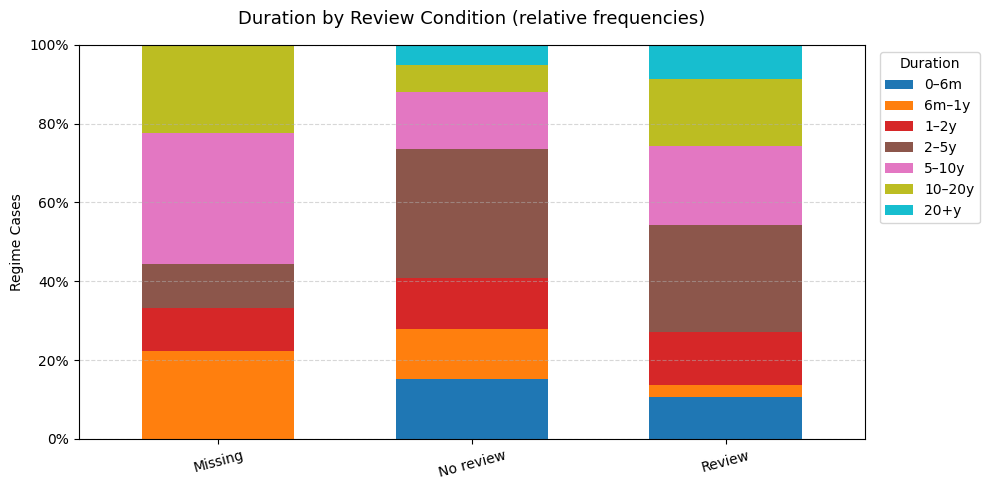

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/review_x_duration.svg


In [5]:
plt.plot_review_x_duration(con)

In [6]:
print("\nFrequency distribution of requirement termination by duration intervall\n")
desc.get_req_termination_x_duration(con)


Frequency distribution of requirement termination by duration intervall



0–6m        6m–1y        1–2y        2–5y        5–10y         \
          Abs. Rel(%)  Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)  Abs. Rel(%)   
Ambiguous   11   10.3     8    7.5   14   13.1   27   25.2    22   20.6   
Clear       42   14.6    30   10.5   37   12.9   93   32.4    44   15.3   
Missing      0    0.0     0    0.0    1   20.0    1   20.0     1   20.0   
TOTAL       53   13.3    38    9.5   52   13.0  121   30.3    67   16.8   

          10–20y        20+y        Total  
            Abs. Rel(%) Abs. Rel(%)        
Ambiguous     13   12.1   12   11.2   107  
Clear         28    9.8   13    4.5   287  
Missing        2   40.0    0    0.0     5  
TOTAL         43   10.8   25    6.3   399

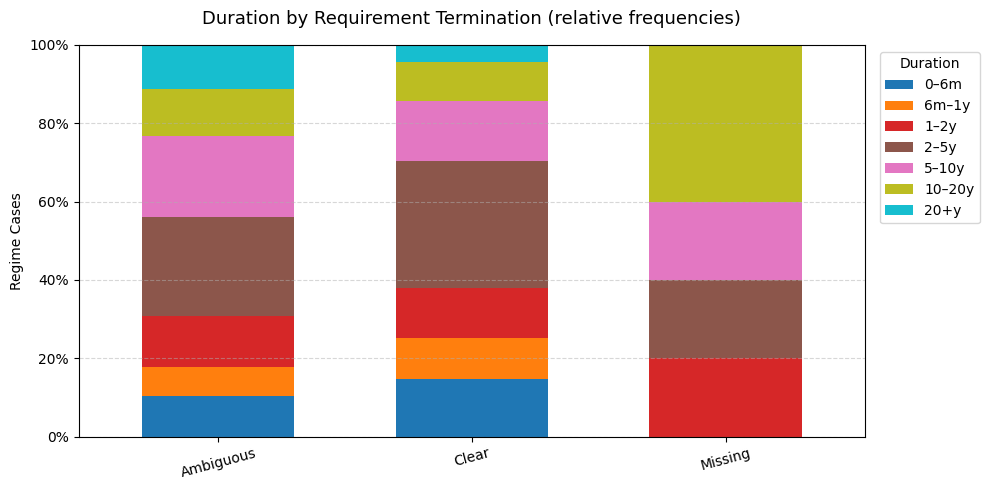

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/req_termination_x_duration.svg


In [7]:
plt.plot_req_termination_x_duration(con)

## Outcome

Variable pairs:

- **expiry-date** x **outcame**
- **review** x **outcame**
- **requirement-termination** x **outcame**

### Data preparation

*Outcome* categories combining a *negotiated settlement* with another outcome
(*sender capitulation*, *target complete acquiescence*, *target partial acquiescence*) were collapsed into the corresponding single-outcome category. The standalone *negotiated settlement* and *Stalemate* categories were dropped due to insufficient case counts. 


In [8]:
print("\nFrequency distribution of expiry by outcome type\n\nFULL DATA\n")
desc.get_expiry_x_outcome(con)


Frequency distribution of expiry by outcome type

FULL DATA



Missing        Negotiated settlement         \
                  Abs. Rel(%)                  Abs. Rel(%)   
Missing              1   14.3                     0    0.0   
Not stipulated      79   24.5                     4    1.2   
Stipulated          28   40.0                     0    0.0   
TOTAL              108   27.1                     4    1.0   

               Negotiated settlement & Sender capitulation         \
                                                      Abs. Rel(%)   
Missing                                                  0    0.0   
Not stipulated                                           1    0.3   
Stipulated                                               1    1.4   
TOTAL                                                    2    0.5   

               Negotiated settlement & Target complete acquiescence         \
                                                               Abs. Rel(%)   
Missing                                                         0      0.0   
Not stipulated                                                  2      0.6   
Stipulated                                                      1      1.4   
TOTAL                                                           3      0.8   

               Negotiated settlement & Target partial acquiescence         \
                                                              Abs. Rel(%)   
Missing                                                         1    14.3   
Not stipulated                                                  6     1.9   
Stipulated                                                      3     4.3   
TOTAL                                                          10     2.5   

               Sender capitulation        Stalemate         \
                              Abs. Rel(%)      Abs. Rel(%)   
Missing                          1   14.3         1   14.3   
Not stipulated                  47   14.6        20    6.2   
Stipulated                       0    0.0         6    8.6   
TOTAL                           48   12.0        27    6.8   

               Target complete acquiescence         \
                                       Abs. Rel(%)   
Missing                                   3   42.9   
Not stipulated                           84   26.1   
Stipulated                               15   21.4   
TOTAL                                   102   25.6   

               Target partial acquiescence        Total  
                                      Abs. Rel(%)        
Missing                                  0    0.0     7  
Not stipulated                          79   24.5   322  
Stipulated                              16   22.9    70  
TOTAL                                   95   23.8   399

In [9]:
print("\nPROCESSED DATA\n")
expiry_x_outcome = desc.get_expiry_x_outcome(con)
hlp.normalize_table_for_visual(expiry_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
                  Abs. Rel(%)                Abs. Rel(%)   
Missing              1   16.7                   1   16.7   
Not stipulated      79   26.5                  48   16.1   
Stipulated          28   43.8                   1    1.6   
TOTAL              108   29.3                  50   13.6   

               Target complete acquiescence         \
                                       Abs. Rel(%)   
Missing                                   3   50.0   
Not stipulated                           86   28.9   
Stipulated                               16   25.0   
TOTAL                                   105   28.5   

               Target partial acquiescence        Total  
                                      Abs. Rel(%)        
Missing                                  1   16.7     6  
Not stipulated                          85   28.5   298  
Stipulated                              19   29.7    64  
TOTAL                                  105   28.5   368

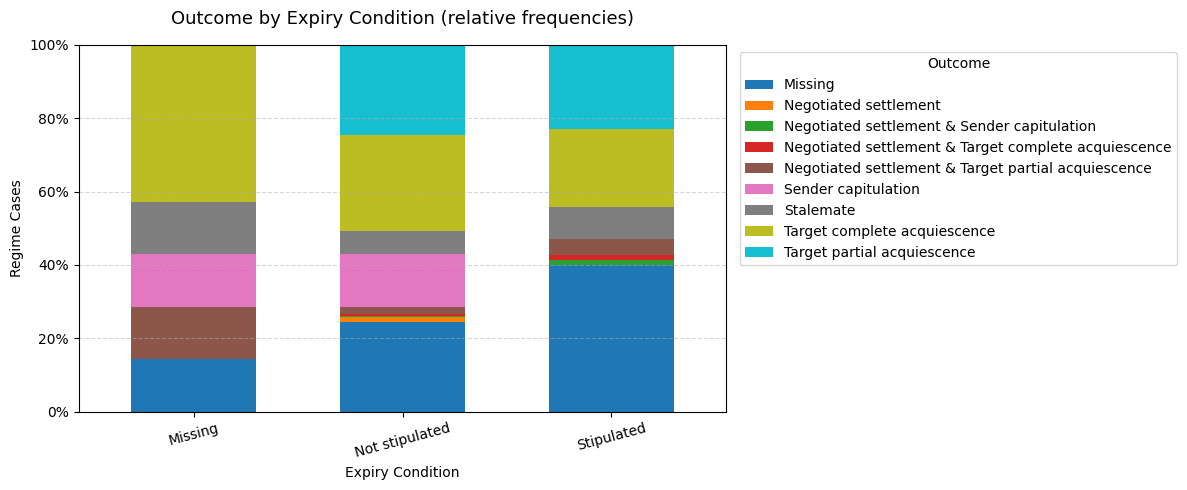

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/expiry_x_outcome.svg


In [10]:
plt.plot_expiry_x_outcome(con)

In [11]:
print("\nFrequency distribution of review by outcome type\n\nFULL DATA\n")
desc.get_review_x_outcome(con)


Frequency distribution of review by outcome type

FULL DATA



Missing        Negotiated settlement         \
             Abs. Rel(%)                  Abs. Rel(%)   
Missing         1   11.1                     0    0.0   
No review      45   18.0                     4    1.6   
Review         62   44.3                     0    0.0   
TOTAL         108   27.1                     4    1.0   

          Negotiated settlement & Sender capitulation         \
                                                 Abs. Rel(%)   
Missing                                             0    0.0   
No review                                           2    0.8   
Review                                              0    0.0   
TOTAL                                               2    0.5   

          Negotiated settlement & Target complete acquiescence         \
                                                          Abs. Rel(%)   
Missing                                                    0      0.0   
No review                                                  2      0.8   
Review                                                     1      0.7   
TOTAL                                                      3      0.8   

          Negotiated settlement & Target partial acquiescence         \
                                                         Abs. Rel(%)   
Missing                                                    1    11.1   
No review                                                  8     3.2   
Review                                                     1     0.7   
TOTAL                                                     10     2.5   

          Sender capitulation        Stalemate         \
                         Abs. Rel(%)      Abs. Rel(%)   
Missing                     1   11.1         1   11.1   
No review                  37   14.8        16    6.4   
Review                     10    7.1        10    7.1   
TOTAL                      48   12.0        27    6.8   

          Target complete acquiescence        Target partial acquiescence  \
                                  Abs. Rel(%)                        Abs.   
Missing                              3   33.3                           2   
No review                           74   29.6                          62   
Review                              25   17.9                          31   
TOTAL                              102   25.6                          95   

                 Total  
          Rel(%)        
Missing     22.2     9  
No review   24.8   250  
Review      22.1   140  
TOTAL       23.8   399

In [12]:
print("\nPROCESSED DATA\n")
review_x_outcome = desc.get_review_x_outcome(con)
hlp.normalize_table_for_visual(review_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
             Abs. Rel(%)                Abs. Rel(%)   
Missing         1   12.5                   1   12.5   
No review      45   19.6                  39   17.0   
Review         62   47.7                  10    7.7   
TOTAL         108   29.3                  50   13.6   

          Target complete acquiescence        Target partial acquiescence  \
                                  Abs. Rel(%)                        Abs.   
Missing                              3   37.5                           3   
No review                           76   33.0                          70   
Review                              26   20.0                          32   
TOTAL                              105   28.5                         105   

                 Total  
          Rel(%)        
Missing     37.5     8  
No review   30.4   230  
Review      24.6   130  
TOTAL       28.5   368

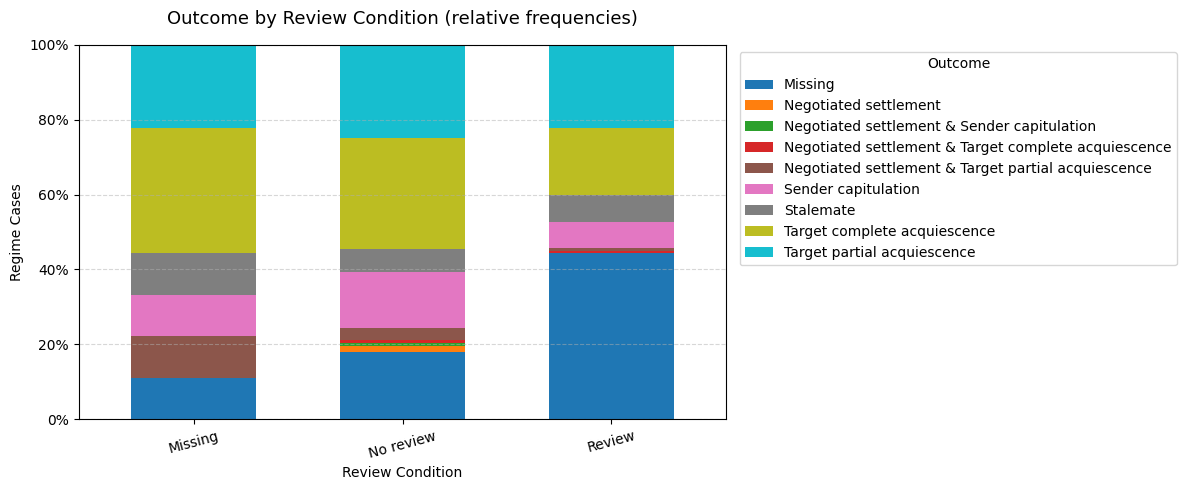

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/review_x_outcome.svg


In [13]:
plt.plot_review_x_outcome(con)

In [14]:
print("\nFrequency distribution of requirement terminations by outcome type\n\nFULL DATA\n")
desc.get_req_termination_x_outcome(con)


Frequency distribution of requirement terminations by outcome type

FULL DATA



Missing        Negotiated settlement         \
           Abs. Rel(%)                  Abs. Rel(%)   
0.0          45   42.1                     1    0.9   
1.0          63   22.0                     3    1.0   
Missing       0    0.0                     0    0.0   
TOTAL       108   27.1                     4    1.0   

        Negotiated settlement & Sender capitulation         \
                                               Abs. Rel(%)   
0.0                                               0    0.0   
1.0                                               2    0.7   
Missing                                           0    0.0   
TOTAL                                             2    0.5   

        Negotiated settlement & Target complete acquiescence         \
                                                        Abs. Rel(%)   
0.0                                                      0      0.0   
1.0                                                      3      1.0   
Missing                                                  0      0.0   
TOTAL                                                    3      0.8   

        Negotiated settlement & Target partial acquiescence         \
                                                       Abs. Rel(%)   
0.0                                                      5     4.7   
1.0                                                      5     1.7   
Missing                                                  0     0.0   
TOTAL                                                   10     2.5   

        Sender capitulation        Stalemate         \
                       Abs. Rel(%)      Abs. Rel(%)   
0.0                       9    8.4         9    8.4   
1.0                      39   13.6        18    6.3   
Missing                   0    0.0         0    0.0   
TOTAL                    48   12.0        27    6.8   

        Target complete acquiescence        Target partial acquiescence  \
                                Abs. Rel(%)                        Abs.   
0.0                               20   18.7                          18   
1.0                               79   27.5                          75   
Missing                            3   60.0                           2   
TOTAL                            102   25.6                          95   

               Total  
        Rel(%)        
0.0       16.8   107  
1.0       26.1   287  
Missing   40.0     5  
TOTAL     23.8   399

In [15]:
print("\nPROCESSED DATA\n")
termination_x_outcome = desc.get_req_termination_x_outcome(con)
hlp.normalize_table_for_visual(termination_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
           Abs. Rel(%)                Abs. Rel(%)   
0.0          45   46.4                   9    9.3   
1.0          63   23.7                  41   15.4   
Missing       0    0.0                   0    0.0   
TOTAL       108   29.3                  50   13.6   

        Target complete acquiescence        Target partial acquiescence  \
                                Abs. Rel(%)                        Abs.   
0.0                               20   20.6                          23   
1.0                               82   30.8                          80   
Missing                            3   60.0                           2   
TOTAL                            105   28.5                         105   

               Total  
        Rel(%)        
0.0       23.7    97  
1.0       30.1   266  
Missing   40.0     5  
TOTAL     28.5   368

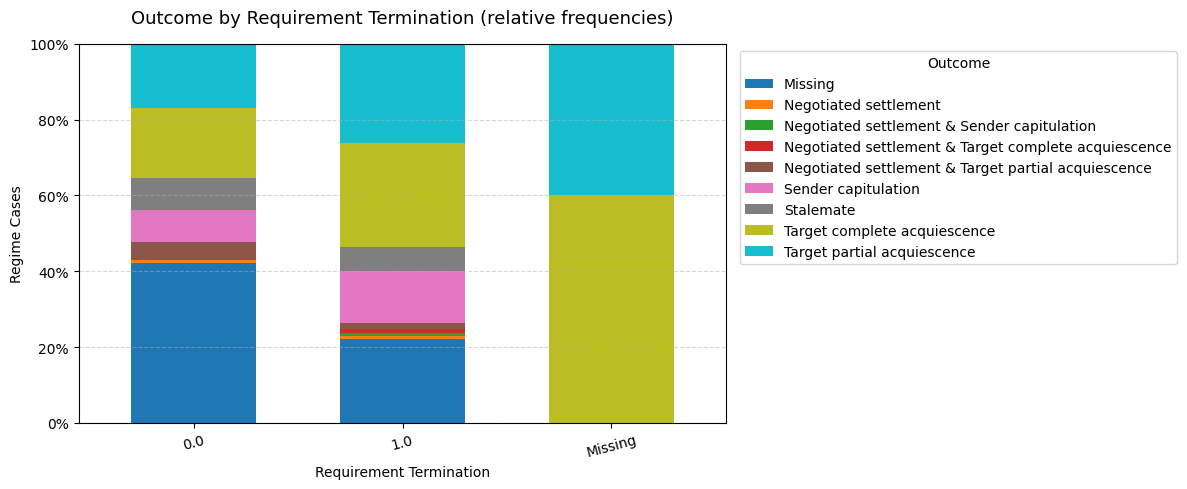

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/req_termination_x_outcome.svg


In [16]:
plt.plot_req_termination_x_outcome(con)

## Sender

Variable pairs:

- **expiry-date** x **sender**
- **review** x **sender**
- **requirement-termination** x **sender**

In [17]:
print("\nFrequency distribution of expiry-date by sender type\n")
desc.get_expiry_x_sender(con)


Frequency distribution of expiry-date by sender type



CommSec         EAC        ECOWAS         EEC        EEC & EU  \
                  Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)     Abs.   
Missing              0    0.0    0    0.0      0    0.0    0    0.0        1   
Not stipulated       6    1.9    1    0.3      9    2.8    4    1.2       13   
Stipulated           1    1.4    0    0.0      0    0.0    1    1.4        3   
TOTAL                7    1.8    1    0.3      9    2.3    5    1.3       17   

                       ...    OAU SADC          UM          UN         USA  \
               Rel(%)  ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%) Abs.   
Missing          14.3  ...    0.0    0    0.0    0    0.0    0    0.0    5   
Not stipulated    4.0  ...    4.0    1    0.3    1    0.3   20    6.2  215   
Stipulated        4.3  ...    1.4    0    0.0    0    0.0   12   17.1   25   
TOTAL             4.3  ...    3.5    1    0.3    1    0.3   32    8.0  245   

                      Total  
               Rel(%)        
Missing          71.4     7  
Not stipulated   66.8   322  
Stipulated       35.7    70  
TOTAL            61.4   399  

[4 rows x 27 columns]

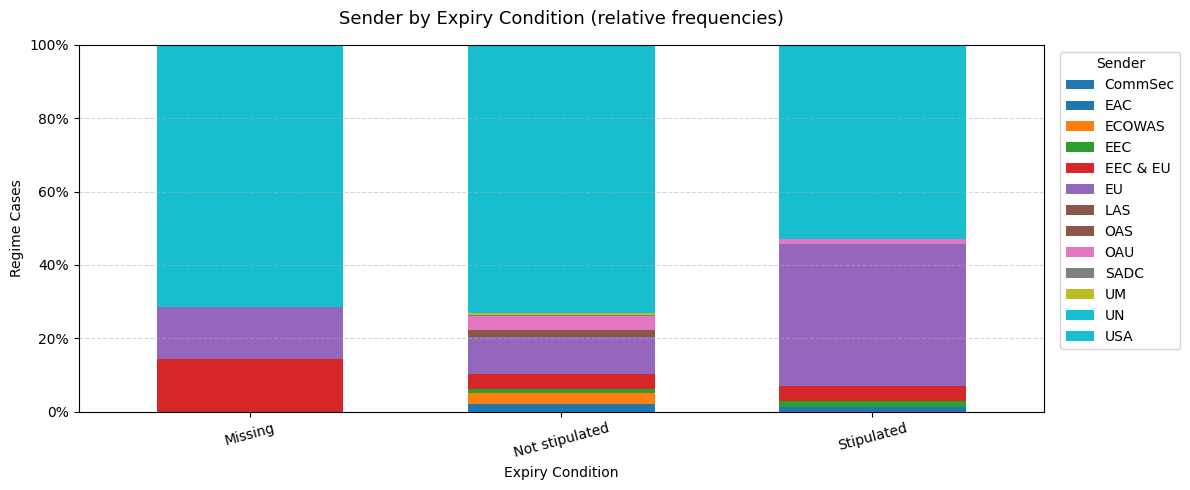

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/expiry_x_sender.svg


In [18]:
plt.plot_expiry_x_sender(con)

In [19]:
print("\nFrequency distribution of review by sender type\n")
desc.get_review_x_sender(con)


Frequency distribution of review by sender type



CommSec         EAC        ECOWAS         EEC        EEC & EU  \
             Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)     Abs.   
Missing         0    0.0    0    0.0      0    0.0    1   11.1        1   
No review       5    2.0    1    0.4      9    3.6    4    1.6        9   
Review          2    1.4    0    0.0      0    0.0    0    0.0        7   
TOTAL           7    1.8    1    0.3      9    2.3    5    1.3       17   

                  ...    OAU SADC          UM          UN         USA         \
          Rel(%)  ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)   
Missing     11.1  ...    0.0    0    0.0    0    0.0    0    0.0    6   66.7   
No review    3.6  ...    4.8    1    0.4    1    0.4    8    3.2  154   61.6   
Review       5.0  ...    1.4    0    0.0    0    0.0   24   17.1   85   60.7   
TOTAL        4.3  ...    3.5    1    0.3    1    0.3   32    8.0  245   61.4   

          Total  
                 
Missing       9  
No review   250  
Review      140  
TOTAL       399  

[4 rows x 27 columns]

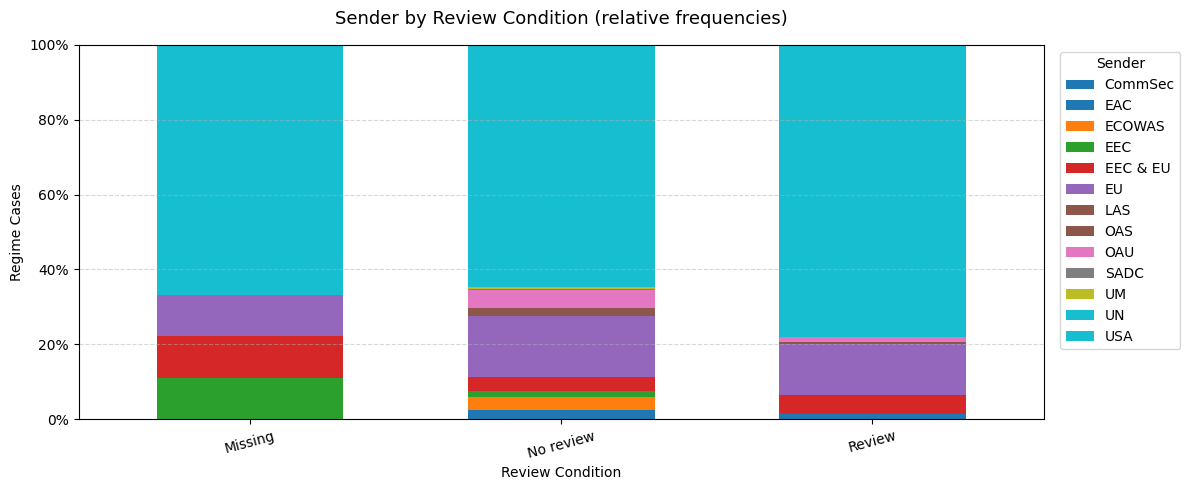

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/review_x_sender.svg


In [20]:
plt.plot_review_x_sender(con)

In [21]:
print("\nFrequency distribution of requirement terminations by sender type\n")
desc.get_req_termination_x_sender(con)


Frequency distribution of requirement terminations by sender type



CommSec         EAC        ECOWAS         EEC        EEC & EU         \
           Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)     Abs. Rel(%)   
0.0           1    0.9    0    0.0      1    0.9    1    0.9        8    7.5   
1.0           6    2.1    1    0.3      8    2.8    3    1.0        9    3.1   
Missing       0    0.0    0    0.0      0    0.0    1   20.0        0    0.0   
TOTAL         7    1.8    1    0.3      9    2.3    5    1.3       17    4.3   

         ...    OAU SADC          UM          UN         USA        Total  
         ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)        
0.0      ...    0.0    0    0.0    1    0.9    3    2.8   75   70.1   107  
1.0      ...    4.9    1    0.3    0    0.0   29   10.1  166   57.8   287  
Missing  ...    0.0    0    0.0    0    0.0    0    0.0    4   80.0     5  
TOTAL    ...    3.5    1    0.3    1    0.3   32    8.0  245   61.4   399  

[4 rows x 27 columns]

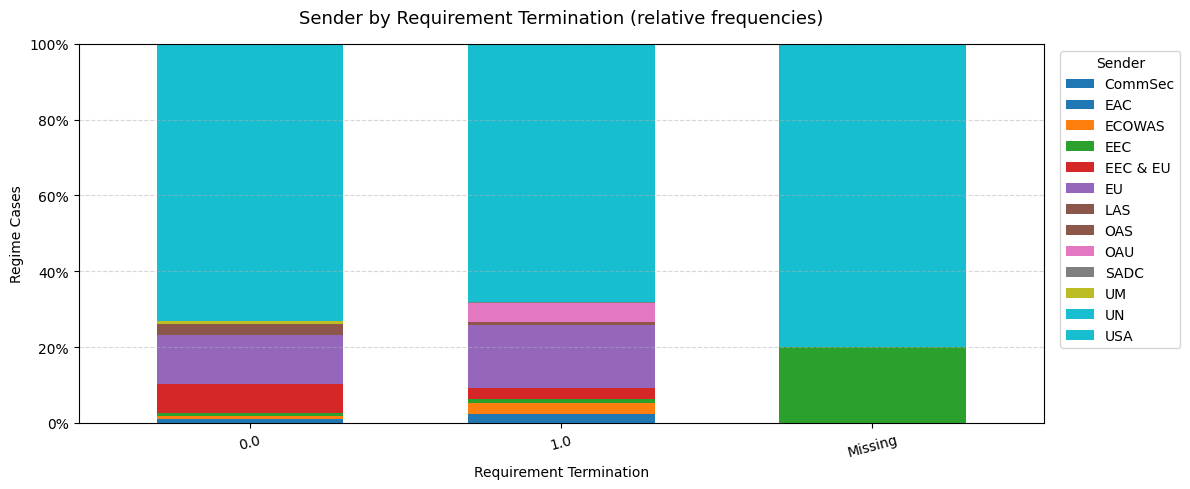

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/req_termination_x_sender.svg


In [22]:
plt.plot_req_termination_x_sender(con)

## Duration

Variable pairs:

- **gradual** x **duration**
- **negotiations** x **duration**

In [23]:
print("\nFrequency distribution of gradual condition by duration\n")
desc.get_gradual_x_duration(con)


Frequency distribution of gradual condition by duration



0–6m        6m–1y        1–2y        2–5y        5–10y         \
            Abs. Rel(%)  Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)  Abs. Rel(%)   
Gradual        1    0.6    10    5.8   10    5.8   60   34.9    38   22.1   
Missing        0    0.0     1   50.0    0    0.0    0    0.0     1   50.0   
Not Gradual   52   23.1    27   12.0   42   18.7   61   27.1    28   12.4   
TOTAL         53   13.3    38    9.5   52   13.0  121   30.3    67   16.8   

            10–20y        20+y        Total  
              Abs. Rel(%) Abs. Rel(%)        
Gradual         30   17.4   23   13.4   172  
Missing          0    0.0    0    0.0     2  
Not Gradual     13    5.8    2    0.9   225  
TOTAL           43   10.8   25    6.3   399

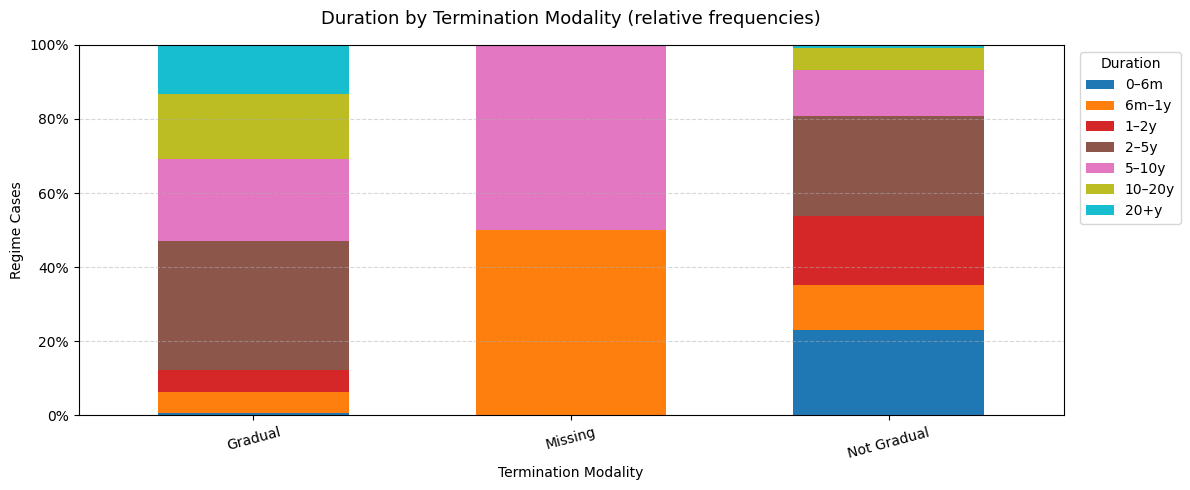

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/gradual_x_duration.svg


In [24]:
plt.plot_gradual_x_duration(con)

In [25]:
print("\nFrequency distribution of negotiations by duration\n")
desc.get_negotiations_x_duration(con)


Frequency distribution of negotiations by duration



0–6m        6m–1y        1–2y        2–5y        5–10y  \
                   Abs. Rel(%)  Abs. Rel(%) Abs. Rel(%) Abs. Rel(%)  Abs.   
Has Negotiations     23    9.5    27   11.2   27   11.2   75   31.1    41   
Lacks Negotiations   30   19.2    11    7.1   25   16.0   46   29.5    25   
Missing               0    0.0     0    0.0    0    0.0    0    0.0     1   
TOTAL                53   13.3    38    9.5   52   13.0  121   30.3    67   

                          10–20y        20+y        Total  
                   Rel(%)   Abs. Rel(%) Abs. Rel(%)        
Has Negotiations     17.0     29   12.0   19    7.9   241  
Lacks Negotiations   16.0     13    8.3    6    3.8   156  
Missing              50.0      1   50.0    0    0.0     2  
TOTAL                16.8     43   10.8   25    6.3   399

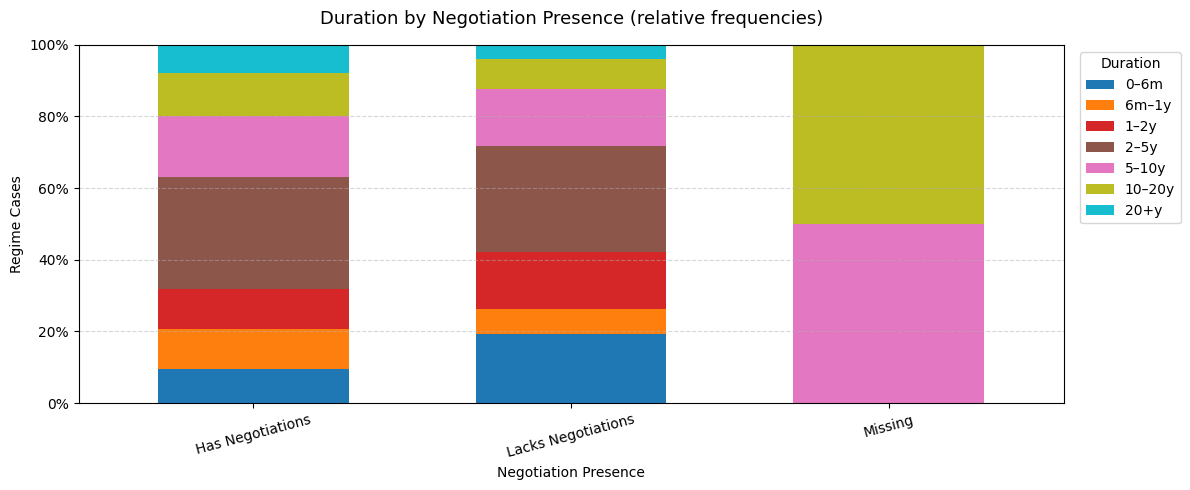

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/negotiations_x_duration.svg


In [26]:
plt.plot_negotiations_x_duration(con)

## Outcome

Variable pairs:

- **gradual** x **outcome**
- **adaptation-goal** x **outcome**
- **negotiations** x **outcome**

In [27]:
print("\nFrequency distribution of gradual condition by outcome\n\nFULL DATA\n")
desc.get_gradual_x_outcome(con)


Frequency distribution of gradual condition by outcome

FULL DATA



Missing        Negotiated settlement         \
               Abs. Rel(%)                  Abs. Rel(%)   
Gradual          48   27.9                     2    1.2   
Missing           0    0.0                     0    0.0   
Not Gradual      60   26.7                     2    0.9   
TOTAL           108   27.1                     4    1.0   

            Negotiated settlement & Sender capitulation         \
                                                   Abs. Rel(%)   
Gradual                                               2    1.2   
Missing                                               0    0.0   
Not Gradual                                           0    0.0   
TOTAL                                                 2    0.5   

            Negotiated settlement & Target complete acquiescence         \
                                                            Abs. Rel(%)   
Gradual                                                      0      0.0   
Missing                                                      0      0.0   
Not Gradual                                                  3      1.3   
TOTAL                                                        3      0.8   

            Negotiated settlement & Target partial acquiescence         \
                                                           Abs. Rel(%)   
Gradual                                                      7     4.1   
Missing                                                      0     0.0   
Not Gradual                                                  3     1.3   
TOTAL                                                       10     2.5   

            Sender capitulation        Stalemate         \
                           Abs. Rel(%)      Abs. Rel(%)   
Gradual                      27   15.7        17    9.9   
Missing                       0    0.0         1   50.0   
Not Gradual                  21    9.3         9    4.0   
TOTAL                        48   12.0        27    6.8   

            Target complete acquiescence        Target partial acquiescence  \
                                    Abs. Rel(%)                        Abs.   
Gradual                               33   19.2                          36   
Missing                                0    0.0                           1   
Not Gradual                           69   30.7                          58   
TOTAL                                102   25.6                          95   

                   Total  
            Rel(%)        
Gradual       20.9   172  
Missing       50.0     2  
Not Gradual   25.8   225  
TOTAL         23.8   399

In [28]:
print("\nPROCESSED DATA\n")
gradual_x_outcome = desc.get_gradual_x_outcome(con)
hlp.normalize_table_for_visual(gradual_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
               Abs. Rel(%)                Abs. Rel(%)   
Gradual          48   31.4                  29   19.0   
Missing           0    0.0                   0    0.0   
Not Gradual      60   28.0                  21    9.8   
TOTAL           108   29.3                  50   13.6   

            Target complete acquiescence        Target partial acquiescence  \
                                    Abs. Rel(%)                        Abs.   
Gradual                               33   21.6                          43   
Missing                                0    0.0                           1   
Not Gradual                           72   33.6                          61   
TOTAL                                105   28.5                         105   

                   Total  
            Rel(%)        
Gradual       28.1   153  
Missing      100.0     1  
Not Gradual   28.5   214  
TOTAL         28.5   368

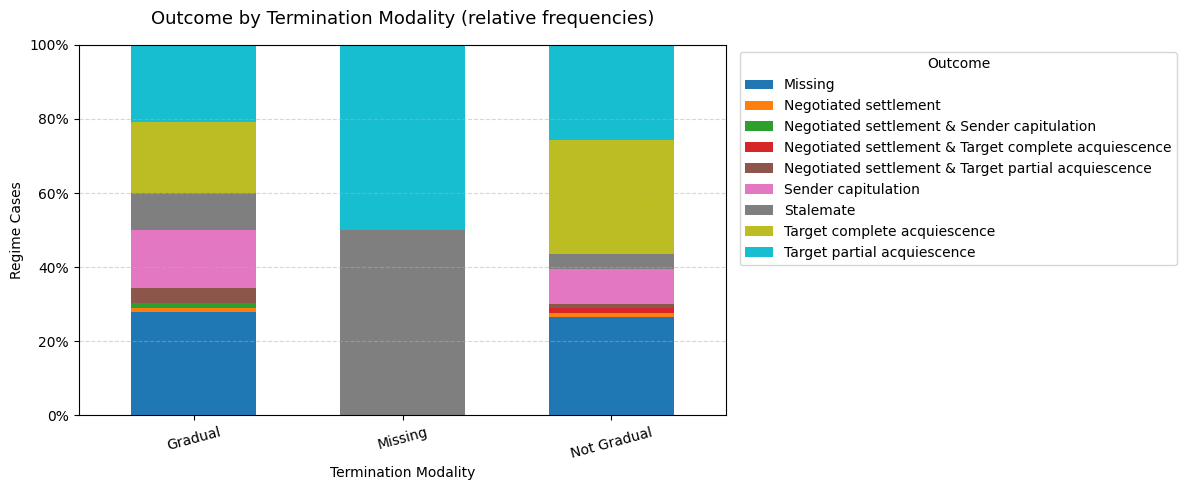

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/gradual_x_outcome.svg


In [29]:
plt.plot_gradual_x_outcome(con)

In [30]:
print("\nFrequency distribution of adaptation-goal by outcome\n\nFULL DATA\n")
desc.get_adapt_goal_x_outcome(con)


Frequency distribution of adaptation-goal by outcome

FULL DATA



Missing        Negotiated settlement         \
               Abs. Rel(%)                  Abs. Rel(%)   
Adapted          15   31.9                     1    2.1   
Missing           0    0.0                     0    0.0   
Not Adapted      93   26.6                     3    0.9   
TOTAL           108   27.1                     4    1.0   

            Negotiated settlement & Sender capitulation         \
                                                   Abs. Rel(%)   
Adapted                                               1    2.1   
Missing                                               0    0.0   
Not Adapted                                           1    0.3   
TOTAL                                                 2    0.5   

            Negotiated settlement & Target complete acquiescence         \
                                                            Abs. Rel(%)   
Adapted                                                      0      0.0   
Missing                                                      0      0.0   
Not Adapted                                                  3      0.9   
TOTAL                                                        3      0.8   

            Negotiated settlement & Target partial acquiescence         \
                                                           Abs. Rel(%)   
Adapted                                                      1     2.1   
Missing                                                      0     0.0   
Not Adapted                                                  9     2.6   
TOTAL                                                       10     2.5   

            Sender capitulation        Stalemate         \
                           Abs. Rel(%)      Abs. Rel(%)   
Adapted                       0    0.0         6   12.8   
Missing                       0    0.0         0    0.0   
Not Adapted                  48   13.8        21    6.0   
TOTAL                        48   12.0        27    6.8   

            Target complete acquiescence        Target partial acquiescence  \
                                    Abs. Rel(%)                        Abs.   
Adapted                                7   14.9                          16   
Missing                                2   66.7                           1   
Not Adapted                           93   26.6                          78   
TOTAL                                102   25.6                          95   

                   Total  
            Rel(%)        
Adapted       34.0    47  
Missing       33.3     3  
Not Adapted   22.3   349  
TOTAL         23.8   399

In [31]:
print("\nPROCESSED DATA\n")
adapt_goal_x_outcome = desc.get_adapt_goal_x_outcome(con)
hlp.normalize_table_for_visual(adapt_goal_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
               Abs. Rel(%)                Abs. Rel(%)   
Adapted          15   37.5                   1    2.5   
Missing           0    0.0                   0    0.0   
Not Adapted      93   28.6                  49   15.1   
TOTAL           108   29.3                  50   13.6   

            Target complete acquiescence        Target partial acquiescence  \
                                    Abs. Rel(%)                        Abs.   
Adapted                                7   17.5                          17   
Missing                                2   66.7                           1   
Not Adapted                           96   29.5                          87   
TOTAL                                105   28.5                         105   

                   Total  
            Rel(%)        
Adapted       42.5    40  
Missing       33.3     3  
Not Adapted   26.8   325  
TOTAL         28.5   368

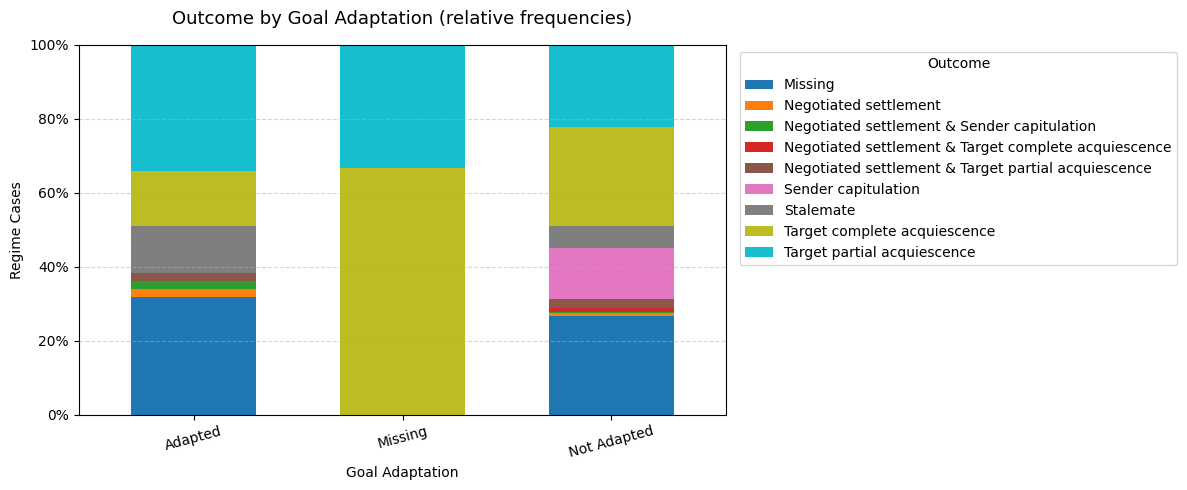

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/adapt_goal_x_outcome.svg


In [32]:
plt.plot_adapt_goal_x_outcome(con)

In [33]:
print("\nFrequency distribution of negotiations by outcome\n\nFULL DATA\n")
desc.get_negotiations_x_outcome(con)


Frequency distribution of negotiations by outcome

FULL DATA



Missing        Negotiated settlement         \
                      Abs. Rel(%)                  Abs. Rel(%)   
Has Negotiations        53   22.0                     4    1.7   
Lacks Negotiations      55   35.3                     0    0.0   
Missing                  0    0.0                     0    0.0   
TOTAL                  108   27.1                     4    1.0   

                   Negotiated settlement & Sender capitulation         \
                                                          Abs. Rel(%)   
Has Negotiations                                             2    0.8   
Lacks Negotiations                                           0    0.0   
Missing                                                      0    0.0   
TOTAL                                                        2    0.5   

                   Negotiated settlement & Target complete acquiescence  \
                                                                   Abs.   
Has Negotiations                                                    3     
Lacks Negotiations                                                  0     
Missing                                                             0     
TOTAL                                                               3     

                          Negotiated settlement & Target partial acquiescence  \
                   Rel(%)                                                Abs.   
Has Negotiations      1.2                                                 10    
Lacks Negotiations    0.0                                                  0    
Missing               0.0                                                  0    
TOTAL                 0.8                                                 10    

                          Sender capitulation        Stalemate         \
                   Rel(%)                Abs. Rel(%)      Abs. Rel(%)   
Has Negotiations      4.1                  32   13.3        14    5.8   
Lacks Negotiations    0.0                  16   10.3        13    8.3   
Missing               0.0                   0    0.0         0    0.0   
TOTAL                 2.5                  48   12.0        27    6.8   

                   Target complete acquiescence         \
                                           Abs. Rel(%)   
Has Negotiations                             63   26.1   
Lacks Negotiations                           37   23.7   
Missing                                       2  100.0   
TOTAL                                       102   25.6   

                   Target partial acquiescence        Total  
                                          Abs. Rel(%)        
Has Negotiations                            60   24.9   241  
Lacks Negotiations                          35   22.4   156  
Missing                                      0    0.0     2  
TOTAL                                       95   23.8   399

In [34]:
print("\nPROCESSED DATA\n")
negotiations_x_outcome = desc.get_negotiations_x_outcome(con)
hlp.normalize_table_for_visual(negotiations_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
                      Abs. Rel(%)                Abs. Rel(%)   
Has Negotiations        53   23.8                  34   15.2   
Lacks Negotiations      55   38.5                  16   11.2   
Missing                  0    0.0                   0    0.0   
TOTAL                  108   29.3                  50   13.6   

                   Target complete acquiescence         \
                                           Abs. Rel(%)   
Has Negotiations                             66   29.6   
Lacks Negotiations                           37   25.9   
Missing                                       2  100.0   
TOTAL                                       105   28.5   

                   Target partial acquiescence        Total  
                                          Abs. Rel(%)        
Has Negotiations                            70   31.4   223  
Lacks Negotiations                          35   24.5   143  
Missing                                      0    0.0     2  
TOTAL                                      105   28.5   368

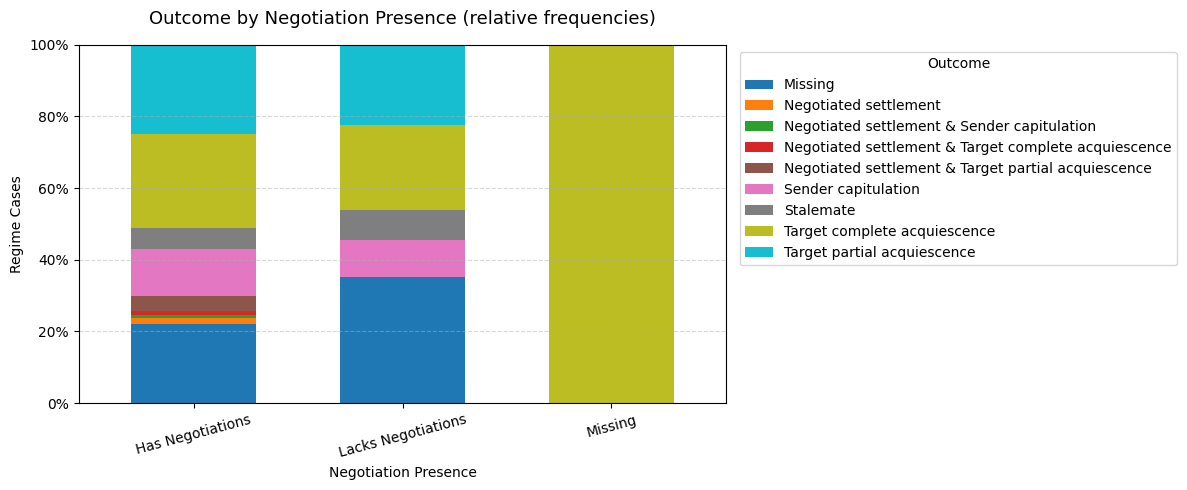

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/negotiations_x_outcome.svg


In [35]:
plt.plot_negotiations_x_outcome(con)

## Sender

Variable pairs:

- **gradual** x **sender**
- **adaptation-goal** x **sender**
- **negotiations** x **sender**

In [36]:
print("\nFrequency distribution of gradual condition by sender\n")
desc.get_gradual_x_sender(con)


Frequency distribution of gradual condition by sender



CommSec         EAC        ECOWAS         EEC        EEC & EU  \
               Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)     Abs.   
Gradual           0    0.0    1    0.6      0    0.0    0    0.0       12   
Missing           0    0.0    0    0.0      0    0.0    0    0.0        0   
Not Gradual       7    3.1    0    0.0      9    4.0    5    2.2        5   
TOTAL             7    1.8    1    0.3      9    2.3    5    1.3       17   

                    ...    OAU SADC          UM          UN         USA  \
            Rel(%)  ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%) Abs.   
Gradual        7.0  ...    0.6    0    0.0    0    0.0   16    9.3  117   
Missing        0.0  ...    0.0    0    0.0    0    0.0    0    0.0    2   
Not Gradual    2.2  ...    5.8    1    0.4    1    0.4   16    7.1  126   
TOTAL          4.3  ...    3.5    1    0.3    1    0.3   32    8.0  245   

                   Total  
            Rel(%)        
Gradual       68.0   172  
Missing      100.0     2  
Not Gradual   56.0   225  
TOTAL         61.4   399  

[4 rows x 27 columns]

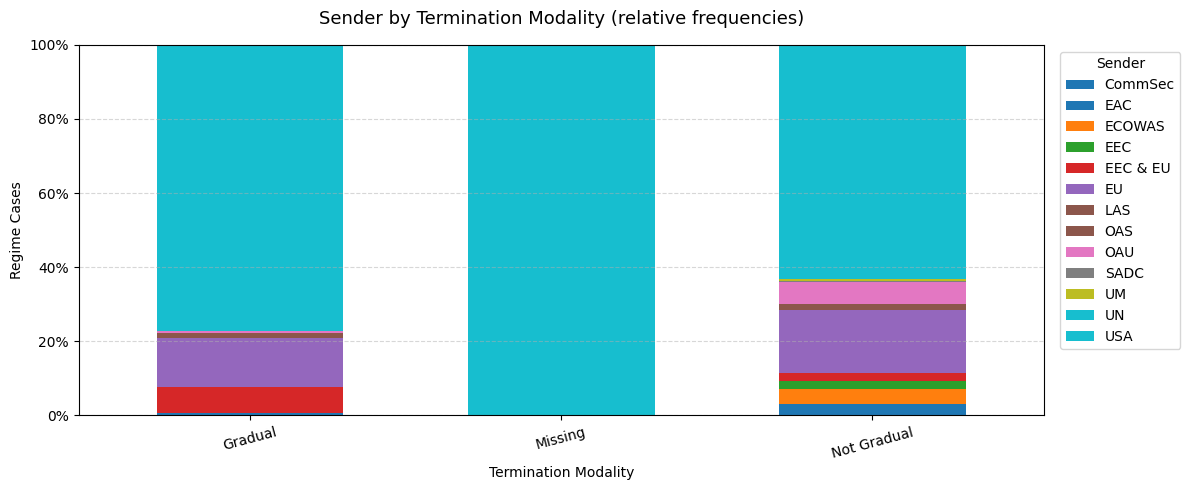

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/gradual_x_sender.svg


In [37]:
plt.plot_gradual_x_sender(con)

In [38]:
print("\nFrequency distribution of adaptation-goal by sender\n")
desc.get_adapt_goal_x_sender(con)


Frequency distribution of adaptation-goal by sender



CommSec         EAC        ECOWAS         EEC        EEC & EU  \
               Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)     Abs.   
Adapted           0    0.0    0    0.0      0    0.0    0    0.0        3   
Missing           0    0.0    0    0.0      0    0.0    0    0.0        0   
Not Adapted       7    2.0    1    0.3      9    2.6    5    1.4       14   
TOTAL             7    1.8    1    0.3      9    2.3    5    1.3       17   

                    ...    OAU SADC          UM          UN         USA  \
            Rel(%)  ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs. Rel(%) Abs.   
Adapted        6.4  ...    0.0    0    0.0    0    0.0    9   19.1   27   
Missing        0.0  ...    0.0    0    0.0    0    0.0    0    0.0    3   
Not Adapted    4.0  ...    4.0    1    0.3    1    0.3   23    6.6  215   
TOTAL          4.3  ...    3.5    1    0.3    1    0.3   32    8.0  245   

                   Total  
            Rel(%)        
Adapted       57.4    47  
Missing      100.0     3  
Not Adapted   61.6   349  
TOTAL         61.4   399  

[4 rows x 27 columns]

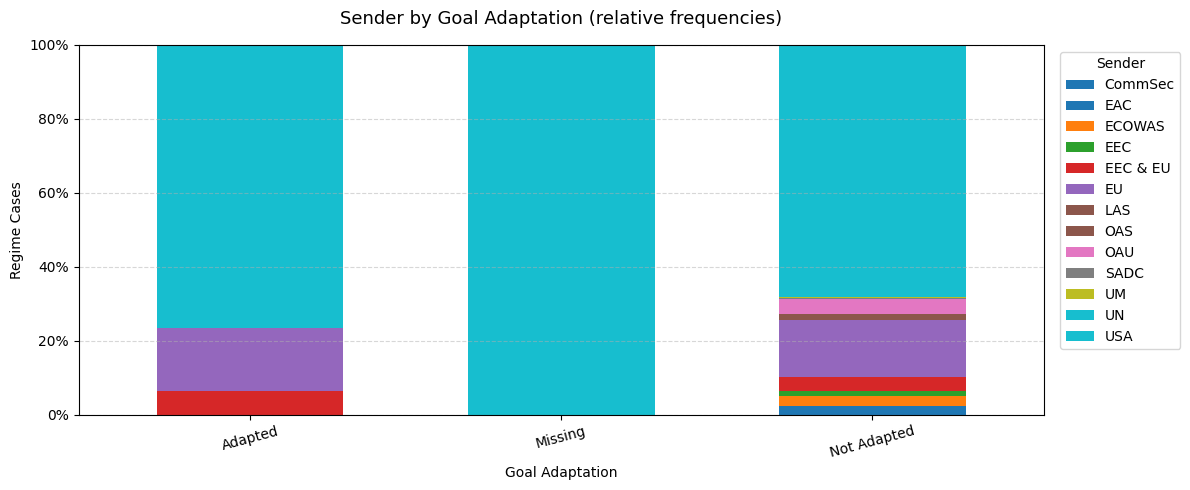

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/adapt_goal_x_sender.svg


In [39]:
plt.plot_adapt_goal_x_sender(con)

In [40]:
print("\nFrequency distribution of negotiations by sender\n")
desc.get_negotiations_x_sender(con)


Frequency distribution of negotiations by sender



CommSec         EAC        ECOWAS         EEC         \
                     Abs. Rel(%) Abs. Rel(%)   Abs. Rel(%) Abs. Rel(%)   
Has Negotiation         3    1.2    1    0.4      8    3.3    2    0.8   
Lacks Negotiation       4    2.6    0    0.0      1    0.6    3    1.9   
Missing                 0    0.0    0    0.0      0    0.0    0    0.0   
TOTAL                   7    1.8    1    0.3      9    2.3    5    1.3   

                  EEC & EU         ...    OAU SADC          UM          UN  \
                      Abs. Rel(%)  ... Rel(%) Abs. Rel(%) Abs. Rel(%) Abs.   
Has Negotiation         11    4.6  ...    4.1    1    0.4    0    0.0   20   
Lacks Negotiation        6    3.8  ...    2.6    0    0.0    1    0.6   12   
Missing                  0    0.0  ...    0.0    0    0.0    0    0.0    0   
TOTAL                   17    4.3  ...    3.5    1    0.3    1    0.3   32   

                          USA        Total  
                  Rel(%) Abs. Rel(%)        
Has Negotiation      8.3  140   58.1   241  
Lacks Negotiation    7.7  103   66.0   156  
Missing              0.0    2  100.0     2  
TOTAL                8.0  245   61.4   399  

[4 rows x 27 columns]

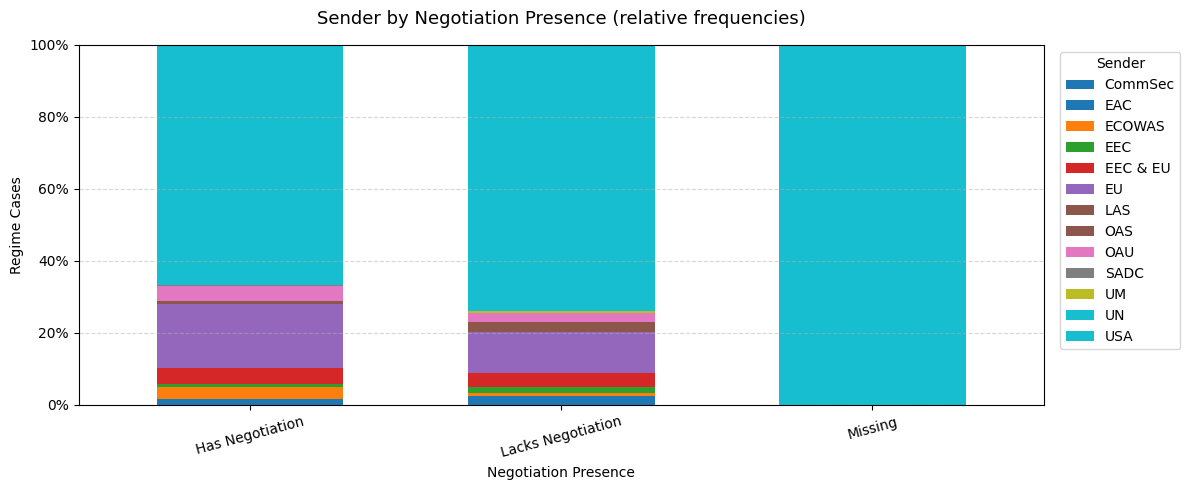

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/negotiations_x_sender.svg


In [41]:
plt.plot_negotiations_x_sender(con)

## Outcome

Variable pairs:

- **multilateralism** x **outcome**
- **duration** x **outcome**
- **gradual** x **outcome**

In [42]:
print("\nFrequency distribution of multilateralism by outcome\n\nFULL DATA\n")
desc.get_multilateralism_x_outcome(con)


Frequency distribution of multilateralism by outcome

FULL DATA



Missing        Negotiated settlement         \
                Abs. Rel(%)                  Abs. Rel(%)   
Multilateral      51   25.8                     3    1.5   
Unilateral        57   28.4                     1    0.5   
TOTAL            108   27.1                     4    1.0   

             Negotiated settlement & Sender capitulation         \
                                                    Abs. Rel(%)   
Multilateral                                           0    0.0   
Unilateral                                             2    1.0   
TOTAL                                                  2    0.5   

             Negotiated settlement & Target complete acquiescence         \
                                                             Abs. Rel(%)   
Multilateral                                                  1      0.5   
Unilateral                                                    2      1.0   
TOTAL                                                         3      0.8   

             Negotiated settlement & Target partial acquiescence         \
                                                            Abs. Rel(%)   
Multilateral                                                  1     0.5   
Unilateral                                                    9     4.5   
TOTAL                                                        10     2.5   

             Sender capitulation        Stalemate         \
                            Abs. Rel(%)      Abs. Rel(%)   
Multilateral                   6    3.0        18    9.1   
Unilateral                    42   20.9         9    4.5   
TOTAL                         48   12.0        27    6.8   

             Target complete acquiescence        Target partial acquiescence  \
                                     Abs. Rel(%)                        Abs.   
Multilateral                           69   34.8                          49   
Unilateral                             33   16.4                          46   
TOTAL                                 102   25.6                          95   

                    Total  
             Rel(%)        
Multilateral   24.7   198  
Unilateral     22.9   201  
TOTAL          23.8   399

In [43]:
print("\nPROCESSED DATA\n")
multilateralism_x_outcome = desc.get_multilateralism_x_outcome(con)
hlp.normalize_table_for_visual(multilateralism_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation         \
                Abs. Rel(%)                Abs. Rel(%)   
Multilateral      51   28.8                   6    3.4   
Unilateral        57   29.8                  44   23.0   
TOTAL            108   29.3                  50   13.6   

             Target complete acquiescence        Target partial acquiescence  \
                                     Abs. Rel(%)                        Abs.   
Multilateral                           70   39.5                          50   
Unilateral                             35   18.3                          55   
TOTAL                                 105   28.5                         105   

                    Total  
             Rel(%)        
Multilateral   28.2   177  
Unilateral     28.8   191  
TOTAL          28.5   368

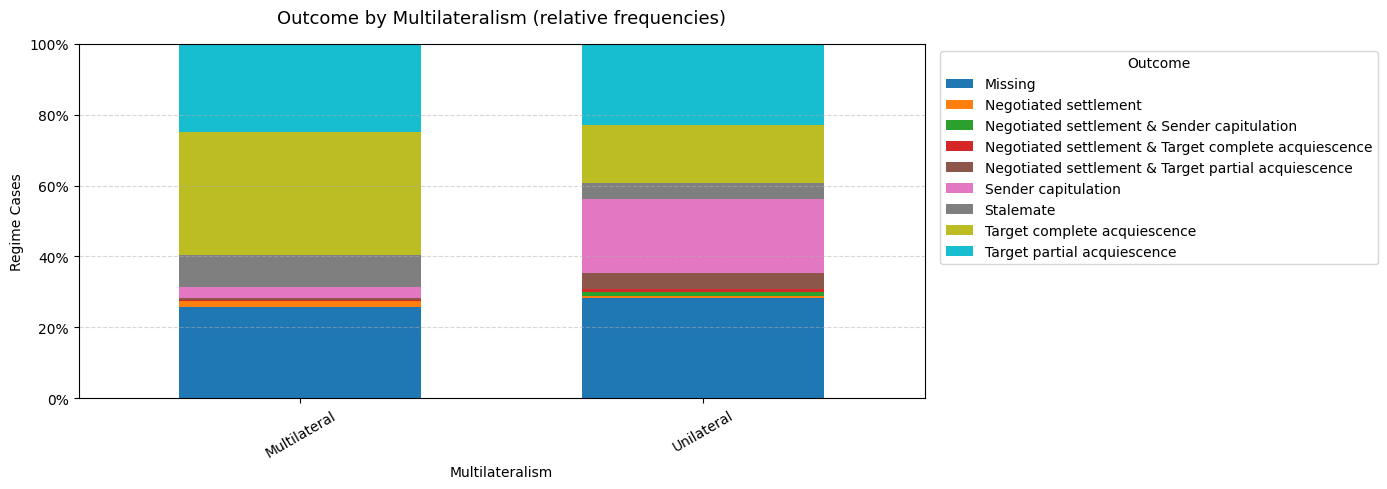

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/multilateralism_x_outcome.svg


In [44]:
plt.plot_multilateralism_x_outcome(con)

In [45]:
print("\nFrequency distribution of duration interval by outcome\n\nFULL DATA\n")
desc.get_duration_x_outcome(con)


Frequency distribution of duration interval by outcome

FULL DATA



Missing        Negotiated settlement         \
          Abs. Rel(%)                  Abs. Rel(%)   
0–6m        19   35.8                     0    0.0   
6m–1y        1    2.6                     1    2.6   
1–2y        12   23.1                     1    1.9   
2–5y        24   19.8                     1    0.8   
5–10y       20   29.9                     0    0.0   
10–20y      18   41.9                     1    2.3   
20+y        14   56.0                     0    0.0   
TOTAL      108   27.1                     4    1.0   

       Negotiated settlement & Sender capitulation         \
                                              Abs. Rel(%)   
0–6m                                             0    0.0   
6m–1y                                            0    0.0   
1–2y                                             0    0.0   
2–5y                                             0    0.0   
5–10y                                            0    0.0   
10–20y                                           1    2.3   
20+y                                             1    4.0   
TOTAL                                            2    0.5   

       Negotiated settlement & Target complete acquiescence         \
                                                       Abs. Rel(%)   
0–6m                                                    1      1.9   
6m–1y                                                   1      2.6   
1–2y                                                    1      1.9   
2–5y                                                    0      0.0   
5–10y                                                   0      0.0   
10–20y                                                  0      0.0   
20+y                                                    0      0.0   
TOTAL                                                   3      0.8   

       Negotiated settlement & Target partial acquiescence         \
                                                      Abs. Rel(%)   
0–6m                                                    0     0.0   
6m–1y                                                   2     5.3   
1–2y                                                    1     1.9   
2–5y                                                    3     2.5   
5–10y                                                   0     0.0   
10–20y                                                  2     4.7   
20+y                                                    2     8.0   
TOTAL                                                  10     2.5   

       Sender capitulation        Stalemate         \
                      Abs. Rel(%)      Abs. Rel(%)   
0–6m                     3    5.7         2    3.8   
6m–1y                    5   13.2         9   23.7   
1–2y                     6   11.5         1    1.9   
2–5y                    15   12.4         8    6.6   
5–10y                   16   23.9         4    6.0   
10–20y                   1    2.3         0    0.0   
20+y                     2    8.0         3   12.0   
TOTAL                   48   12.0        27    6.8   

       Target complete acquiescence        Target partial acquiescence         \
                               Abs. Rel(%)                        Abs. Rel(%)   
0–6m                             19   35.8                           9   17.0   
6m–1y                            11   28.9                           8   21.1   
1–2y                             18   34.6                          12   23.1   
2–5y                             29   24.0                          41   33.9   
5–10y                            13   19.4                          14   20.9   
10–20y                            9   20.9                          11   25.6   
20+y                              3   12.0                           0    0.0   
TOTAL                           102   25.6                          95   23.8   

       Total  
              
0–6m      53  
6m–1y     38  
1–2y      52  
2–5y     121  
5–10y     67  
10–20y

In [46]:
print("\nPROCESSED DATA\n")
get_duration_x_outcome = desc.get_duration_x_outcome(con)
hlp.normalize_table_for_visual(get_duration_x_outcome, cont.outcome_mapping)


PROCESSED DATA



Missing        Sender capitulation        Target complete acquiescence  \
          Abs. Rel(%)                Abs. Rel(%)                         Abs.   
0–6m        19   37.3                   3    5.9                           20   
6m–1y        1    3.6                   5   17.9                           12   
1–2y        12   24.0                   6   12.0                           19   
2–5y        24   21.4                  15   13.4                           29   
5–10y       20   31.7                  16   25.4                           13   
10–20y      18   42.9                   2    4.8                            9   
20+y        14   63.6                   3   13.6                            3   
TOTAL      108   29.3                  50   13.6                          105   

              Target partial acquiescence        Total  
       Rel(%)                        Abs. Rel(%)        
0–6m     39.2                           9   17.6    51  
6m–1y    42.9                          10   35.7    28  
1–2y     38.0                          13   26.0    50  
2–5y     25.9                          44   39.3   112  
5–10y    20.6                          14   22.2    63  
10–20y   21.4                          13   31.0    42  
20+y     13.6                           2    9.1    22  
TOTAL    28.5                         105   28.5   368

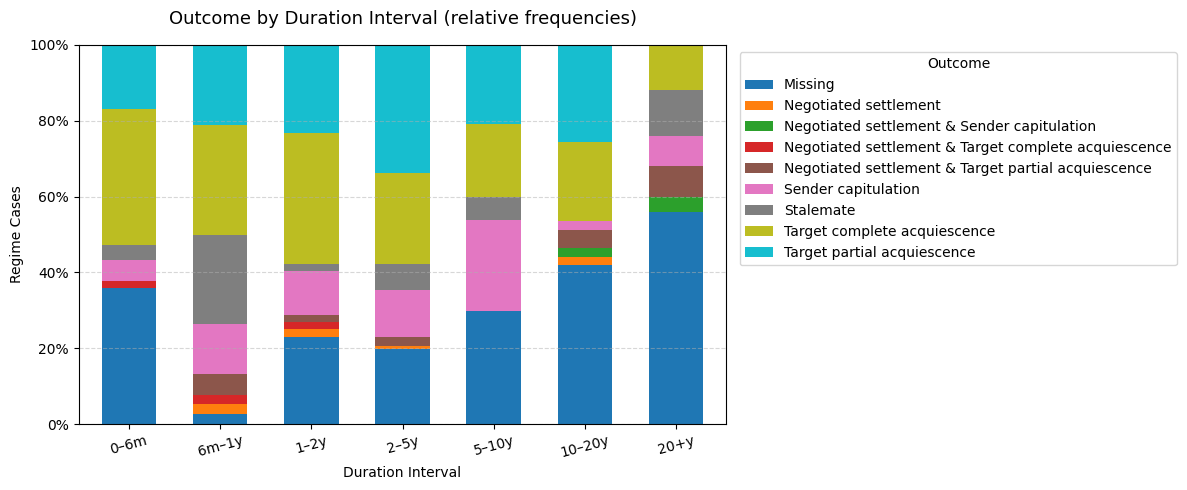

Plot saved to: /home/ljutach/auri_projects/sanctions-termination-dataset/data_visual/bivariate/duration_x_outcome.svg


In [47]:
plt.plot_duration_x_outcome(con)